In [6]:
# =========================
# 1. IMPORTS
# =========================

import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

In [7]:
# =========================
# 2. PATHS + DEVICE
# =========================

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SPLIT_DIR = BASE_DIR / "data" / "splits"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Base directory:", BASE_DIR)
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Base directory: D:\Git\eshani-2026\e_wardrobe_ai
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [8]:
# =========================
# 3. LOAD SPLIT DATA
# =========================

train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (24266, 11)
Validation: (5200, 11)
Test: (5201, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,usage,productDisplayName,image_path,image_exists
0,59410,Women,Apparel,Topwear,Tshirts,White,Fall,Casual,Tokyo Talkies Women Multi Coloured T-shirt,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
1,16387,Men,Apparel,Topwear,Shirts,Orange,Fall,Formal,Peter England Men Stripes Orange Shirt,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
2,8125,Men,Accessories,Belts,Belts,Black,Winter,Casual,Fastrack Men Black Belt,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
3,12320,Men,Apparel,Topwear,Shirts,Brown,Fall,Formal,Genesis Men Brown Striped Shirt,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True
4,40760,Men,Accessories,Bags,Backpacks,Blue,Summer,Casual,Quiksilver Men Blue & Black Backpack,D:\Git\eshani-2026\e_wardrobe_ai\data\raw\imag...,True


In [9]:
# =========================
# 4. CREATE LABEL MAPPING
# =========================

target_col = "articleType"

classes = sorted(train_df[target_col].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

num_classes = len(classes)

print("Number of classes:", num_classes)
print(class_to_idx)

with open(MODEL_DIR / "articleType_class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=4)

Number of classes: 23
{'Backpacks': 0, 'Belts': 1, 'Briefs': 2, 'Casual Shoes': 3, 'Flats': 4, 'Flip Flops': 5, 'Formal Shoes': 6, 'Handbags': 7, 'Heels': 8, 'Jeans': 9, 'Kurtas': 10, 'Perfume and Body Mist': 11, 'Sandals': 12, 'Shirts': 13, 'Shorts': 14, 'Socks': 15, 'Sports Shoes': 16, 'Sunglasses': 17, 'Tops': 18, 'Trousers': 19, 'Tshirts': 20, 'Wallets': 21, 'Watches': 22}


In [10]:
# =========================
# 5. IMAGE TRANSFORMS
# =========================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
# =========================
# 6. DATASET CLASS
# =========================

class WardrobeDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_path = row["image_path"]
        label_name = row["articleType"]
        label = self.class_to_idx[label_name]

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (224, 224), color=(255, 255, 255))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [12]:
# =========================
# 7. DATASETS + DATALOADERS
# =========================

BATCH_SIZE = 32

train_dataset = WardrobeDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = WardrobeDataset(val_df, class_to_idx, transform=eval_transform)
test_dataset = WardrobeDataset(test_df, class_to_idx, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 759
Validation batches: 163
Test batches: 163


In [13]:
# =========================
# 8. BUILD MOBILENETV2 MODEL
# =========================

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

print("Model ready.")

Model ready.


In [14]:
# =========================
# 9. LOSS + OPTIMIZER
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [15]:
# =========================
# 10. TRAIN FUNCTION
# =========================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [16]:
# =========================
# 11. VALIDATION FUNCTION
# =========================

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [17]:
# =========================
# 12. TRAIN MODEL
# =========================

EPOCHS = 5
best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = MODEL_DIR / "mobilenetv2_articleType_best.pth"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

print("\nTraining completed.")
print("Best validation accuracy:", best_val_acc)
print("Model saved to:", best_model_path)


Epoch 1/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [01:21<00:00,  2.01it/s]


Train Loss: 0.7428 | Train Acc: 0.7794
Val Loss:   0.2971 | Val Acc:   0.8946
Best model saved.

Epoch 2/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [00:19<00:00,  8.20it/s]


Train Loss: 0.2759 | Train Acc: 0.9040
Val Loss:   0.2359 | Val Acc:   0.9088
Best model saved.

Epoch 3/5
----------------------------------------


...

Train Loss: 0.2216 | Train Acc: 0.9202
Val Loss:   0.2113 | Val Acc:   0.9227
Best model saved.

Epoch 4/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [00:20<00:00,  8.01it/s]


Train Loss: 0.1824 | Train Acc: 0.9344
Val Loss:   0.2228 | Val Acc:   0.9194

Epoch 5/5
----------------------------------------


100%|████████████████████████████████████████| 163/163 [00:19<00:00,  8.20it/s]

Train Loss: 0.1617 | Train Acc: 0.9398
Val Loss:   0.2089 | Val Acc:   0.9260
Best model saved.

Training completed.
Best validation accuracy: 0.9259615384615385
Model saved to: D:\Git\eshani-2026\e_wardrobe_ai\models\mobilenetv2_articleType_best.pth


In [18]:
# =========================
# 13. SAVE TRAINING HISTORY
# =========================

history_path = MODEL_DIR / "mobilenetv2_training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved to:", history_path)

Training history saved to: D:\Git\eshani-2026\e_wardrobe_ai\models\mobilenetv2_training_history.json


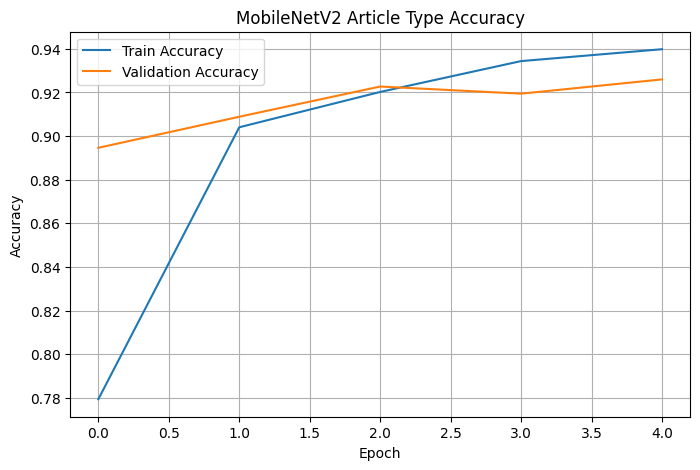

In [19]:
# =========================
# 14. PLOT ACCURACY
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("MobileNetV2 Article Type Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

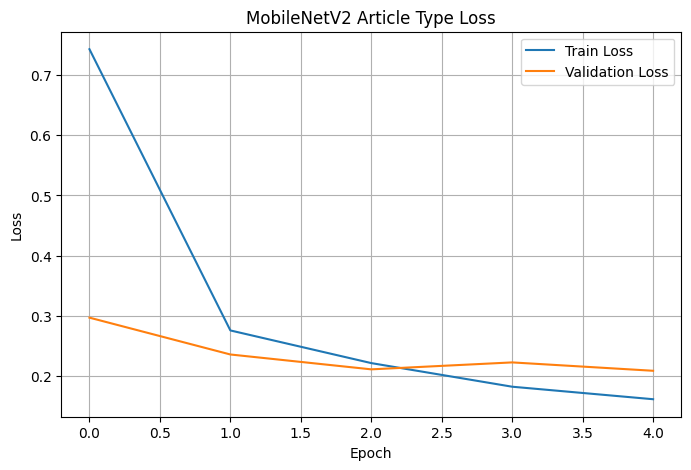

In [20]:
# =========================
# 15. PLOT LOSS
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Article Type Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()